# Figures

Run from the repository root, with the raw OULAD files in `raw/` (see README).

In [ ]:
import os
from pathlib import Path

root = Path.cwd()
for p in [root, *root.parents]:
    if (p / "raw").is_dir():
        root = p
        break
BASE = str(root)

In [ ]:
!pip install econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 8.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd, numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from econml.dml import CausalForestDML, LinearDML
from scipy.stats import pearsonr

oue = pd.read_csv(BASE + '/oulad_ouelluminate_subsample.csv')
print(f"N = {len(oue)}")
print(oue['code_module'].value_counts())

oue['imd_band'] = oue['imd_band'].fillna('Missing')
confounders_oue = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                    'disability', 'code_presentation', 'code_module',
                    'num_of_prev_attempts', 'studied_credits']
categorical_oue = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                    'disability', 'code_presentation', 'code_module']

X_oue = oue[confounders_oue]
T_oue = oue['ouelluminate_clicks'].values
Y_oue = oue['performance_gain'].values
X_oue_encoded = pd.get_dummies(X_oue, columns=categorical_oue, drop_first=True)
print(f"\nConfounder matrix shape: {X_oue_encoded.shape}")

r_oue, p_oue = pearsonr(T_oue, Y_oue)
print(f"\nPearson: r={r_oue:.4f}, p={p_oue:.4g}")

ols_design_oue = np.column_stack([T_oue, X_oue_encoded.values])
ols_oue = LinearRegression().fit(ols_design_oue, Y_oue)
print(f"OLS: {ols_oue.coef_[0]:.4f}")

ldml_oue = LinearDML(model_y=HistGradientBoostingRegressor(random_state=42),
                      model_t=HistGradientBoostingRegressor(random_state=42),
                      discrete_treatment=False, cv=5, random_state=42)
ldml_oue.fit(Y_oue, T_oue, X=X_oue_encoded)
ci_oue = ldml_oue.ate_interval(X_oue_encoded)
print(f"Linear DML: {ldml_oue.ate(X_oue_encoded):.4f}, 95% CI: [{ci_oue[0]:.4f}, {ci_oue[1]:.4f}]")

cf_oue = CausalForestDML(model_y=HistGradientBoostingRegressor(random_state=42),
                          model_t=HistGradientBoostingRegressor(random_state=42),
                          discrete_treatment=False, honest=True, min_samples_leaf=15,
                          n_estimators=500, cv=5, random_state=42)
cf_oue.fit(Y_oue, T_oue, X=X_oue_encoded)
cf_ci_oue = cf_oue.ate_interval(X_oue_encoded)
print(f"\nCausalForestDML: {cf_oue.ate(X_oue_encoded):.4f}, 95% CI: [{cf_ci_oue[0]:.4f}, {cf_ci_oue[1]:.4f}]")

import joblib
joblib.dump(cf_oue, BASE + '/cf_ouelluminate_model.pkl')
print("Saved cf_ouelluminate_model.pkl")

In [ ]:
print(oue['code_presentation'].unique())
print(f"code_presentation columns in encoded matrix: {[c for c in X_oue_encoded.columns if 'code_presentation' in c]}")

['2013B']
code_presentation columns in encoded matrix: []


In [ ]:
sd_oue  = oue['ouelluminate_clicks'].std()
ate_oue = cf_oue.ate(X_oue_encoded)
per_sd_oue = ate_oue * sd_oue
print(f"SD of ouelluminate_clicks : {sd_oue:.2f} clicks")
print(f"CausalForestDML ATE       : {ate_oue:.4f} per click")
print(f"Effect per 1-SD increase  : {per_sd_oue:.4f} performance_gain points")

import joblib
full = pd.read_csv(f'{BASE}/oulad_full_corpus.csv')
full['imd_band'] = full['imd_band'].fillna('Missing')

confounders_v2 = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                  'disability', 'code_presentation', 'num_of_prev_attempts',
                  'studied_credits', 'code_module']
categorical_v2 = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                  'disability', 'code_presentation', 'code_module']

cf_canonical = joblib.load(f'{BASE}/cf_canonical_model.pkl')
X_primary = pd.get_dummies(full[confounders_v2],
                           columns=categorical_v2, drop_first=True).astype(float)
assert X_primary.shape[1] == 40, f"expected 40 columns, got {X_primary.shape[1]}"

ate_primary = cf_canonical.ate(X_primary)
assert abs(ate_primary - 0.004786) < 5e-4, f"wrong model: ATE={ate_primary:.6f}"

sd_primary     = full['oucontent_clicks'].std()
per_sd_primary = ate_primary * sd_primary

print(f"\nSD of oucontent_clicks    : {sd_primary:.1f} clicks")
print(f"CausalForestDML ATE       : {ate_primary:.6f} per click")
print(f"Effect per 1-SD increase  : {per_sd_primary:.4f} performance_gain points")

print(f"\nRobustness / primary ratio : {per_sd_oue / per_sd_primary:.1%}")
print("NOTE: the previous hardcoded value of 2.075 came from the pre-correction")

SD of ouelluminate_clicks : 23.50 clicks
CausalForestDML ATE       : 0.0646 per click
Effect per 1-SD increase  : 1.5190 performance_gain points

SD of oucontent_clicks    : 781.7 clicks
CausalForestDML ATE       : 0.004786 per click
Effect per 1-SD increase  : 3.7417 performance_gain points

Robustness / primary ratio : 40.6%
NOTE: the previous hardcoded value of 2.075 came from the pre-correction


/usr/local/lib/python3.13/dist-packages/econml/sklearn_extensions/model_selection.py:554: UserWarning: Model LogisticRegressionCV(cv=5, random_state=42) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


PEHE: 0.6835454424199341
Saved. PEHE this realization: 0.6835454424199341


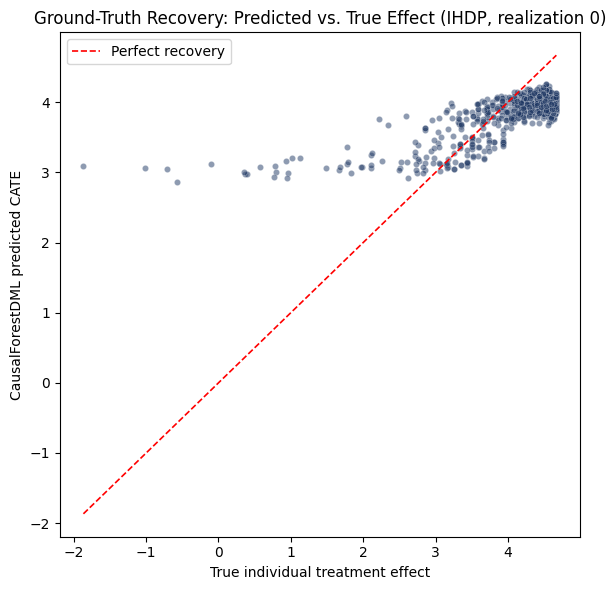

In [ ]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegressionCV

urllib.request.urlretrieve(
    "https://www.fredjo.com/files/ihdp_npci_1-100.train.npz", "ihdp_train.npz")

train = np.load("ihdp_train.npz")
x, t, yf = train['x'][:, :, 0], train['t'][:, 0], train['yf'][:, 0]
mu0, mu1 = train['mu0'][:, 0], train['mu1'][:, 0]
true_ite = mu1 - mu0

cf = CausalForestDML(model_y=GradientBoostingRegressor(random_state=42),
                      model_t=LogisticRegressionCV(cv=5, random_state=42),
                      discrete_treatment=True, honest=True, min_samples_leaf=10,
                      n_estimators=1000, cv=5, random_state=42)
cf.fit(yf, t, X=x)
pred_ite = cf.effect(x)
print("PEHE:", np.sqrt(np.mean((pred_ite - true_ite)**2)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_ite, pred_ite, alpha=0.5, s=20, color="#1F3864", edgecolor="white", linewidth=0.3)
lims = [min(true_ite.min(), pred_ite.min()), max(true_ite.max(), pred_ite.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label="Perfect recovery")
ax.set_xlabel("True individual treatment effect")
ax.set_ylabel("CausalForestDML predicted CATE")
ax.set_title("Ground-Truth Recovery: Predicted vs. True Effect (IHDP, realization 0)")
ax.legend()
plt.tight_layout()

plt.savefig(BASE + '/figure_error_analysis_ihdp.png', dpi=300, bbox_inches='tight')
print("Saved. PEHE this realization:", np.sqrt(np.mean((pred_ite - true_ite)**2)))